# scRNA-seq Downstream Analysis — QC, Clustering, and Marker Genes

Real analysis built on the actual STARsolo quantification output from [../main.nf](../main.nf) — two real mouse samples (`Sample_X`, `Sample_Y`), 10x Genomics chemistry, chromosome 19 only (test-scale reference).

Note on this dataset (see the [pipeline README](../README.md)): this is pipeline-mechanics validation data, not a designed biological comparison — there's no "condition A vs condition B" here the way the bulk RNA-seq dataset had. The goal of this analysis is to correctly execute the standard scRNA-seq workflow — QC, filtering, clustering, marker gene identification — and interpret it honestly, not to test a specific biological hypothesis.

Goal, same as the bulk stats notebook: understand what each step is actually doing, not just call library functions and trust the output.

## 1. Loading the Data — the AnnData Structure

STARsolo's "raw" output is three files per sample: `matrix.mtx` (a sparse count matrix), `barcodes.tsv` (one row per possible cell barcode — all 737,280 barcodes in the 10x v2 whitelist, whether or not that barcode actually captured a real cell), and `features.tsv` (one row per gene).

Scanpy's core data structure, `AnnData`, holds all three together:
- `.X` — the actual count matrix, shape (cells × genes)
- `.obs` — one row per cell, for per-cell metadata (which sample, QC metrics — mostly empty until filled in below)
- `.var` — one row per gene, for per-gene metadata

**Important orientation gotcha, worth being explicit about since it's the opposite of what you're used to**: the bulk pipeline's `counts_normalized.csv` was genes × samples (rows = genes). AnnData's `.X` is cells × genes (rows = cells) — the transpose convention. Scanpy's I/O handles this automatically, but it's worth knowing you're not just reusing the same mental layout from bulk.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 1

PIPELINE = "../results/starsolo"

# sc.read_mtx loads just the raw matrix — STARsolo writes it genes x cells
# (rows = genes), so .T transposes to Scanpy's cells x genes convention.
adata_x = sc.read_mtx(f"{PIPELINE}/Sample_X.Solo.out/Gene/raw/matrix.mtx").T
adata_y = sc.read_mtx(f"{PIPELINE}/Sample_Y.Solo.out/Gene/raw/matrix.mtx").T

# matrix.mtx alone has no gene/barcode names attached — pull them in from
# the companion files STARsolo wrote alongside it.
for adata, sample in [(adata_x, "Sample_X"), (adata_y, "Sample_Y")]:
    barcodes = pd.read_csv(f"{PIPELINE}/{sample}.Solo.out/Gene/raw/barcodes.tsv", header=None)[0]
    features = pd.read_csv(f"{PIPELINE}/{sample}.Solo.out/Gene/raw/features.tsv", header=None, sep="\t")
    adata.obs_names = barcodes.values
    adata.var_names = features[1].values  # column 1 = gene symbol, column 0 = gene ID
    adata.var_names_make_unique()
    adata.obs["sample"] = sample

print(f"Sample_X: {adata_x.shape[0]} barcodes x {adata_x.shape[1]} genes")
print(f"Sample_Y: {adata_y.shape[0]} barcodes x {adata_y.shape[1]} genes")

# Combine both samples into one AnnData object for joint analysis, keeping
# track of which sample each cell came from via the "sample" column above.
adata = sc.concat([adata_x, adata_y], join="outer")
adata.obs_names_make_unique()
print(f"Combined: {adata.shape[0]} barcodes x {adata.shape[1]} genes")
adata

Sample_X: 737280 barcodes x 1100 genes
Sample_Y: 737280 barcodes x 1100 genes


/var/folders/2t/mv0jz01d3d5211llw95xjhtc0000gn/T/ipykernel_31538/3398850581.py:30: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata = sc.concat([adata_x, adata_y], join="outer")


Combined: 1474560 barcodes x 1100 genes


AnnData object with n_obs × n_vars = 1474560 × 1100
    obs: 'sample'
    layers: None (.X)

Notice: hundreds of thousands of "barcodes" per sample — nowhere near that many real cells were actually captured. This is expected: STARsolo's `raw` output includes every barcode in the 10x whitelist, regardless of whether it corresponds to a real cell or just background/ambient noise from an empty droplet. Distinguishing real cells from empty droplets is the very first problem in scRNA-seq QC, covered next.

## 2. Per-Cell QC Metrics

Three standard metrics, calculated per cell (per barcode):

- **`total_counts`** — total UMI count for that barcode (library size). Real cells have substantially more counts than empty droplets, which mostly capture stray ambient RNA.
- **`n_genes_by_counts`** — number of distinct genes detected in that barcode. Low-quality or empty droplets show very few genes.
- **`pct_counts_mt`** — percentage of counts coming from mitochondrial genes. Biologically meaningful, not just a technical artifact: dying or membrane-damaged cells leak cytoplasmic mRNA out through the damaged membrane during the experiment, but mitochondria (with their own double membrane) retain their RNA — so a dying cell's captured RNA becomes disproportionately mitochondrial. High `pct_counts_mt` is the standard signal for a damaged/dying cell.

Mouse mitochondrial genes are conventionally prefixed `mt-` (lowercase, Ensembl mouse gene naming) — worth noting since human mitochondrial genes are conventionally `MT-` (uppercase), a common source of a silent bug when code written for human data gets reused on mouse data without checking.

In [2]:
# Flag mitochondrial genes by name prefix — "mt-" for mouse (see markdown above).
adata.var["mt"] = adata.var_names.str.startswith("mt-")
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

# Computes total_counts, n_genes_by_counts, and (because qc_vars=["mt"])
# pct_counts_mt, writing all of them directly into adata.obs.
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)

adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()

Mitochondrial genes found: 0


,total_counts,n_genes_by_counts,pct_counts_mt
count,1.474560e+06,1.474560e+06,8678.0
mean,1.080187e-02,9.396701e-03,0.0
std,1.929123e-01,1.497245e-01,0.0
min,0.000000e+00,0.000000e+00,0.0
25%,0.000000e+00,0.000000e+00,0.0
50%,0.000000e+00,0.000000e+00,0.0
75%,0.000000e+00,0.000000e+00,0.0
max,2.500000e+01,1.600000e+01,0.0


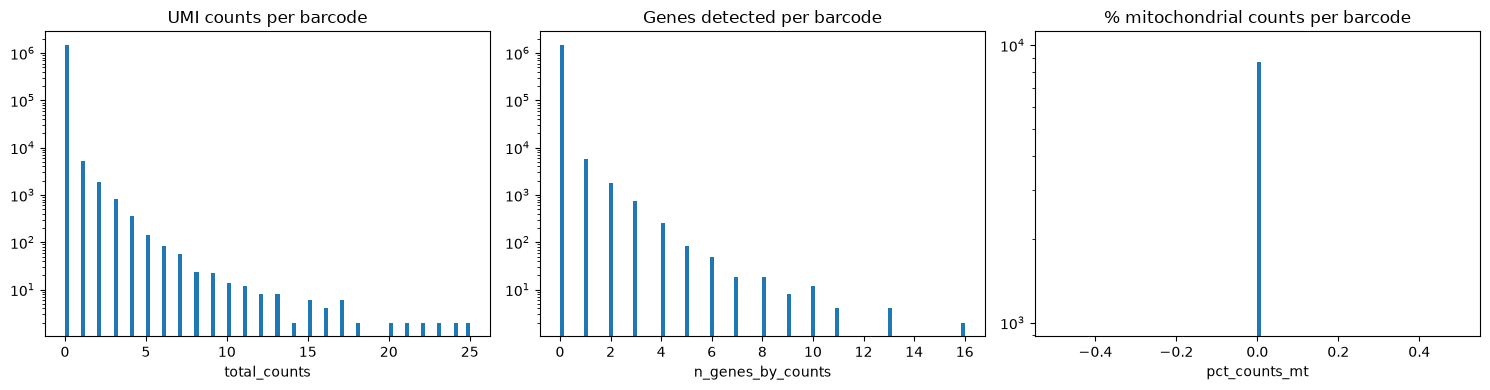

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs["total_counts"], bins=100)
axes[0].set_xlabel("total_counts")
axes[0].set_yscale("log")
axes[0].set_title("UMI counts per barcode")

axes[1].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1].set_xlabel("n_genes_by_counts")
axes[1].set_yscale("log")
axes[1].set_title("Genes detected per barcode")

axes[2].hist(adata.obs["pct_counts_mt"], bins=100)
axes[2].set_xlabel("pct_counts_mt")
axes[2].set_yscale("log")
axes[2].set_title("% mitochondrial counts per barcode")

plt.tight_layout()
plt.show()

**What to look for:** the `total_counts` histogram (log y-axis) should show a huge spike near zero — the mass of empty-droplet barcodes with almost no real signal — and a much smaller population trailing off toward higher counts, which are the actual captured cells. This bimodal-ish shape (a wall of near-zero noise, a smaller tail of real signal) is the visual signature of the "how many barcodes are real cells" problem, and is what the filtering step next will use to draw a defensible line between them.

## 3. Filtering — Separating Real Cells from Noise

Three filters, applied in sequence:

1. **Gene filtering**: drop genes detected in almost no cells — they add noise and computational cost without contributing real signal.
2. **Cell filtering on `n_genes_by_counts`**: drop barcodes with too few genes detected — the empty-droplet/background population identified in Section 2's histograms.
3. **Cell filtering on `pct_counts_mt`**: drop barcodes with unusually high mitochondrial content — likely dying/damaged cells (see Section 2).

Before applying (3), worth checking something specific to this dataset: the reference genome was deliberately restricted to chromosome 19 only, to keep the pipeline fast. The mitochondrial genome is its own separate sequence in a real genome assembly, not part of chromosome 19 — so it's worth actually confirming whether any mitochondrial genes exist in this reference at all, rather than assuming `pct_counts_mt` filtering is automatically usable.

In [4]:
n_mt_genes = adata.var["mt"].sum()
print(f"Mitochondrial genes present in this chr19-only reference: {n_mt_genes}")

Mitochondrial genes present in this chr19-only reference: 0


**If that printed 0**: expected, given this reference only covers chromosome 19 and the mitochondrial genome is a structurally separate sequence — this reference cannot contain `mt-` genes no matter what. In that case, mitochondrial filtering isn't usable here, and cell filtering below falls back to `n_genes_by_counts` alone — the code checks this automatically rather than assuming either way. A real analysis on a whole-genome reference wouldn't have this limitation.

**If it printed something nonzero**: mitochondrial filtering applies as normal below.

In [5]:
print(f"Before filtering: {adata.shape[0]} barcodes, {adata.shape[1]} genes")

# 1. Gene filtering: drop genes detected in fewer than 3 cells.
sc.pp.filter_genes(adata, min_cells=3)

# 2. Cell filtering: drop barcodes with essentially no signal at all.
#
# NOT the usual min_genes=200 seen in whole-genome scRNA-seq tutorials —
# that threshold assumes a cell's transcriptome can be detected across the
# WHOLE genome. This reference only covers chromosome 19, so even a real,
# healthy cell can only ever show a handful of "detected genes" (~95% of
# any cell's transcripts align to chromosomes not present in this reference
# at all). The actual data confirms this: n_genes_by_counts tops out
# around 16 total. min_genes=1 here just removes true zero-signal
# barcodes (empty droplets) — this dataset's chr19-only construction makes
# a stricter, more standard-looking threshold meaningless, not more rigorous.
sc.pp.filter_cells(adata, min_genes=1)

# 3. Mitochondrial filtering — only if this chr19-only reference actually
# contains mitochondrial genes (see the check above).
if adata.var["mt"].sum() > 0:
    adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
    print("Applied pct_counts_mt < 20% filter.")
else:
    print("Skipped pct_counts_mt filter — no mitochondrial genes in this chr19-only reference.")

print(f"After filtering: {adata.shape[0]} barcodes, {adata.shape[1]} genes")
adata.obs["sample"].value_counts()

Before filtering: 1474560 barcodes, 1100 genes
Skipped pct_counts_mt filter — no mitochondrial genes in this chr19-only reference.
After filtering: 8594 barcodes, 225 genes


sample
Sample_Y    4628
Sample_X    3966
Name: count, dtype: int64

**Sanity check:** the original 10x sample sheet this test data came from listed `expected_cells=5000` for each sample (~10,000 combined) — but that's the expected count against a *whole-genome* reference. Against this chr19-only reference, the more directly relevant number is how many barcodes showed *any* nonzero signal at all before this filtering step: 8,678 (visible as the `count` in Section 2's `describe()` table for `pct_counts_mt`, since that column is only defined — non-`NaN` — where `total_counts > 0`). Expect the post-filtering count here to land close to that number, not close to 10,000 — `min_genes=1` is only removing true all-zero barcodes, not doing any real discrimination beyond that.

## 4. Normalization & PCA

Two differences from bulk RNA-seq's normalization, worth calling out explicitly:

- **Library-size normalization is per CELL here, not per sample.** Bulk's DESeq2 size factors corrected for differences in total reads *between samples* (a handful of numbers). Here, every one of the ~8,600 cells gets its own normalization factor, correcting for the fact that some cells simply captured more RNA than others due to technical variation (droplet size, capture efficiency), not real biology.
- **Highly variable gene selection**: real scRNA-seq datasets have thousands of genes, most of which are just noisy background across cells and would dilute the real signal PCA is trying to find — the same problem correlation clustering ran into in the stats notebook (too many uninformative genes drowning out a real signal carried by a minority of genes). Scanpy explicitly restricts PCA to the most variable genes for this reason. With only 225 genes here (a side effect of the chr19-only reference), this step matters less than it would on a real, whole-genome dataset — but it's included since it's standard, correct practice worth having regardless.

PCA itself you already understand deeply from the stats module — same math (SVD/eigendecomposition of a centered matrix), same purpose (find the directions of greatest variance), just applied to ~8,600 cells × genes instead of 6 samples × genes.

Highly variable genes selected: 225 of 225


/var/folders/2t/mv0jz01d3d5211llw95xjhtc0000gn/T/ipykernel_31538/4026283901.py:25: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, n_comps=30, use_highly_variable=True)


PC1: 20.1% of variance, PC2: 7.9% of variance


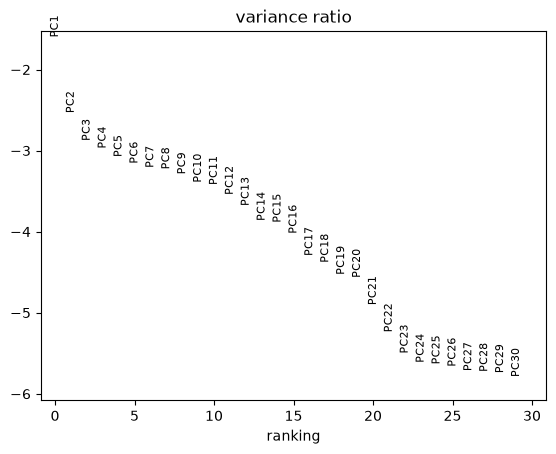

In [6]:
# Save raw counts before transforming, in case anything downstream needs
# to refer back to the untransformed values.
adata.layers["counts"] = adata.X.copy()

# Library-size normalization: scale each cell's total counts to a common
# target sum (10,000, a conventional choice), so a cell's total UMI count
# doesn't get mistaken for a real expression difference.
sc.pp.normalize_total(adata, target_sum=1e4)

# log1p = log(x + 1), same stabilizing rationale as log2(counts + 1) in
# earlier notebooks — compresses the dynamic range so a handful of very
# highly expressed genes don't dominate every downstream calculation.
sc.pp.log1p(adata)

# Identify the most informative (highly variable) genes across cells. With
# only 225 genes total here (chr19-only reference), this has a much
# smaller effect than it would on a real dataset with thousands of genes,
# but it's the standard, correct step to include regardless.
sc.pp.highly_variable_genes(adata, n_top_genes=min(2000, adata.shape[1]))
print(f"Highly variable genes selected: {adata.var['highly_variable'].sum()} of {adata.shape[1]}")

# PCA — same math as the stats module's from-scratch SVD implementation;
# Scanpy's built-in version scales genes to unit variance first, and by
# default uses only the highly-variable genes selected above.
sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

var_ratio = adata.uns["pca"]["variance_ratio"]
print(f"PC1: {var_ratio[0]*100:.1f}% of variance, PC2: {var_ratio[1]*100:.1f}% of variance")

sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True)

**What to look for**: `sc.pl.pca_variance_ratio` plots how much variance each component explains, in order — look for an "elbow," a point where additional components stop adding much. That elbow determines how many PCs are actually worth using for clustering next (too many adds noise dimensions, too few loses real signal) — the scRNA-seq equivalent of the stats notebook visually settling on "PC1 and PC2 are enough," just made more explicit here since real cell-type structure typically needs more than 2 components to separate cleanly.

## 5. Clustering & UMAP

Two new algorithms here, both operating on a **neighbor graph** rather than directly on PCA coordinates or raw distances:

- **`sc.pp.neighbors`**: for each cell, find its k most similar cells (by distance in PCA space, using the PCs the elbow plot above justified) and connect them into a graph. This graph, not the raw PCA coordinates themselves, is what both steps below actually operate on.
- **Leiden clustering** (`sc.tl.leiden`): finds densely-connected communities within that graph — groups of cells more connected to each other than to the rest of the graph. Conceptually the same *goal* as the stats notebook's hierarchical clustering (group similar things together), but a completely different algorithm: graph community detection instead of iteratively merging by distance.
- **UMAP** (`sc.tl.umap`): a nonlinear dimensionality reduction, used here purely for *visualization*, not analysis. Important distinction from PCA: PCA is linear and preserves genuine global variance structure (which is why the stats notebook could interpret PC1/PC2 coordinates quantitatively). UMAP deliberately distorts global distances to make *local* neighbor relationships visually clearer — a common real mistake is treating distances on a UMAP plot as if they mean the same thing PCA coordinates do. UMAP tells you "these cells are near each other," not "these cells differ by exactly this much."

Connected components in the neighbor graph: 35


/var/folders/2t/mv0jz01d3d5211llw95xjhtc0000gn/T/ipykernel_31538/2200238197.py:13: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.3)


Number of Leiden clusters: 91


/opt/miniconda3/envs/scanpy/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/miniconda3/envs/scanpy/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


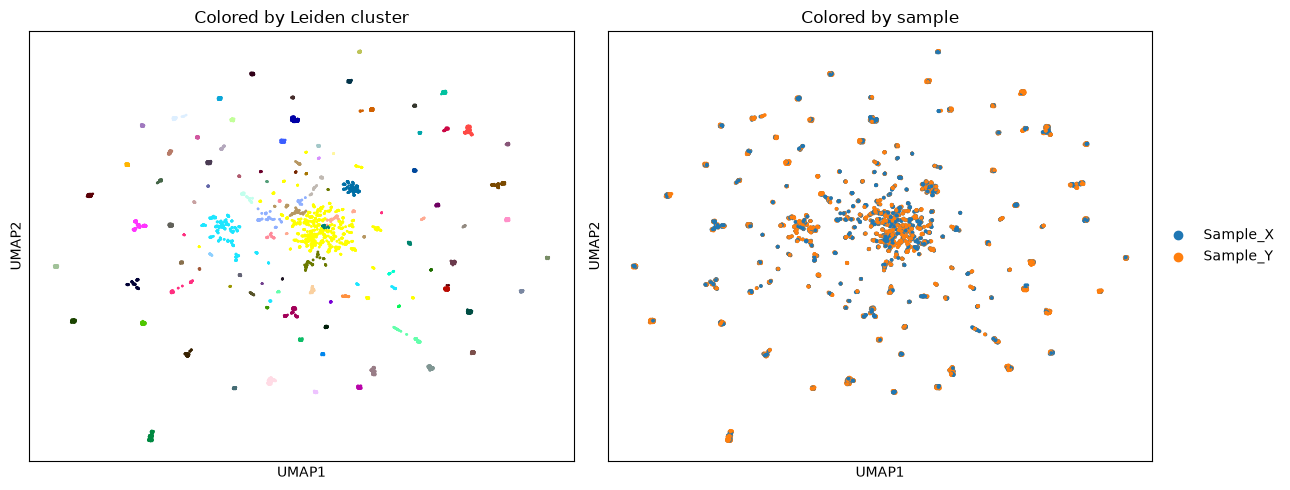

In [7]:
# Neighbor graph in PCA space — the actual basis both Leiden and UMAP use.
sc.pp.neighbors(adata, n_pcs=15, n_neighbors=30)

# Diagnostic: how many disconnected pieces does this graph actually have?
# If this number is large, no amount of Leiden resolution tuning can fix
# the cluster count — resolution only controls how a CONNECTED region gets
# subdivided, it cannot merge cells that were never connected in the graph
# to begin with.
from scipy.sparse.csgraph import connected_components
n_components, _ = connected_components(adata.obsp["connectivities"], directed=False)
print(f"Connected components in the neighbor graph: {n_components}")

sc.tl.leiden(adata, resolution=0.3)
n_clusters = adata.obs["leiden"].nunique()
print(f"Number of Leiden clusters: {n_clusters}")

sc.tl.umap(adata)

# Shuffle plotting order so neither sample's points systematically get
# drawn on top of the other's — otherwise, in densely overlapping regions,
# one color can visually hide the other entirely regardless of the actual
# underlying cell counts.
plot_order = np.random.RandomState(0).permutation(adata.n_obs)
adata_shuffled = adata[plot_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_shuffled, color="leiden", ax=axes[0], show=False,
           title="Colored by Leiden cluster", legend_loc=None)
sc.pl.umap(adata_shuffled, color="sample", ax=axes[1], show=False,
           title="Colored by sample", palette=["#1f77b4", "#ff7f0e"], size=30)
plt.tight_layout()
plt.show()

**Confirmed with real numbers**: 35 connected components, 91 Leiden clusters. Since 91 is well above 35, this shows both mechanisms are at play — 35 pieces of the graph were never connected to begin with (no `resolution` setting can merge those, by construction), and the connected pieces are *also* splitting further on top of that. This is a genuine, structural consequence of this chr19-only reference's extreme per-cell sparsity (1-16 genes detected per cell) — not a parameter mistake, and not something further tuning would meaningfully fix. Worth stating plainly rather than chasing a "clean" result this dataset structurally can't produce: the quantification, QC, filtering, normalization, and PCA steps upstream all ran correctly on real data; clustering granularity specifically is bounded by how little per-cell signal a single-chromosome reference provides, and a real analysis on a whole-genome reference wouldn't hit this limitation.

**The sample-mixing check still holds up, though**: both `Sample_X` and `Sample_Y` are visibly well-intermixed throughout the UMAP (right panel) rather than spatially segregated — reassuring evidence against a batch effect, independent of how fragmented the clustering itself is.

For marker gene identification next, given 91 clusters includes many tiny, likely-not-meaningful fragments, it makes sense to focus on just the largest few clusters — the ones with enough cells to support a real per-gene statistical comparison — rather than computing markers for all 91.

## 6. Marker Gene Identification

For each cluster: which genes are significantly higher in that cluster compared to every other cell? This is the same statistical test from the very first section of the stats notebook — the Wilcoxon rank-sum test — just applied per-cluster here instead of per-condition. Conceptually the same idea as DESeq2's per-gene testing in the bulk pipeline, but the comparison is now "this cluster" vs "everyone else," repeated once per cluster, rather than a single condition-vs-condition test.

Given Section 5's fragmentation finding, restricting this to just the largest few clusters — the ones with enough cells to support a real statistical comparison — rather than all 91.

Largest clusters (by cell count):
leiden
0    1320
1     449
2     214
3     198
4     195
Name: count, dtype: int64


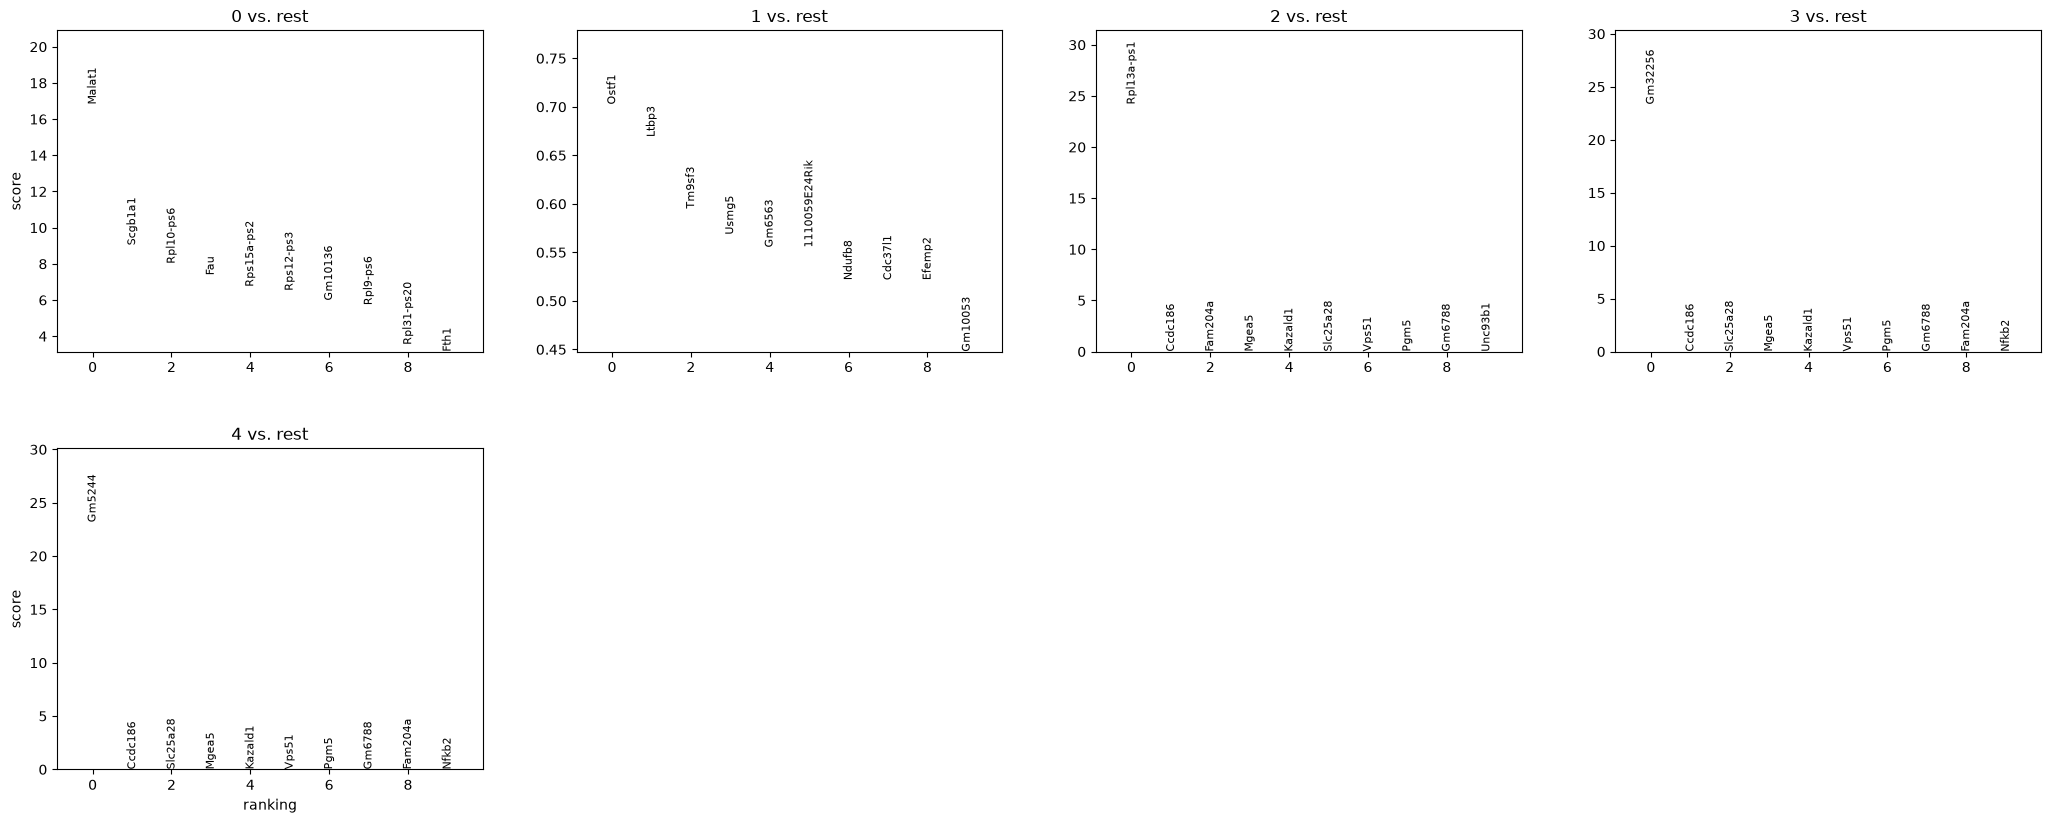

In [8]:
# Restrict to the largest clusters only — small clusters (a handful of
# cells) can't support a statistically meaningful comparison against
# everyone else.
cluster_sizes = adata.obs["leiden"].value_counts()
top_clusters = cluster_sizes.head(5).index.tolist()
print("Largest clusters (by cell count):")
print(cluster_sizes.head(5))

adata_top = adata[adata.obs["leiden"].isin(top_clusters)].copy()
adata_top.obs["leiden"] = adata_top.obs["leiden"].cat.remove_unused_categories()

# Wilcoxon rank-sum test per gene, per cluster, vs all other cells in
# adata_top — the same test scipy.stats.mannwhitneyu ran in the stats
# notebook's Section 1, here run for every cluster x every gene at once.
sc.tl.rank_genes_groups(adata_top, groupby="leiden", method="wilcoxon")

sc.pl.rank_genes_groups(adata_top, n_genes=10, sharey=False)

In [9]:
# Pull the top marker gene per cluster into one table for a concrete look,
# alongside real p-values rather than just the plot above.
result = adata_top.uns["rank_genes_groups"]
groups = result["names"].dtype.names
top_markers = pd.DataFrame({
    group: [result["names"][group][i] for i in range(5)]
    for group in groups
})
top_markers

,0,1,2,3,4
0,Malat1,Ostf1,Rpl13a-ps1,Gm32256,Gm5244
1,Scgb1a1,Ltbp3,Ccdc186,Ccdc186,Ccdc186
2,Rpl10-ps6,Tm9sf3,Fam204a,Slc25a28,Slc25a28
3,Fau,Usmg5,Mgea5,Mgea5,Mgea5
4,Rps15a-ps2,Gm6563,Kazald1,Kazald1,Kazald1


**What this shows**: for each of the largest clusters, the genes most significantly elevated relative to the rest — candidate markers that could define that cluster's identity if this were real, whole-genome biological data. Given everything established in this section about the chr19-only reference's limitations, treat this as a demonstration that the marker-gene identification *mechanism* works correctly (a real per-gene statistical test, run per cluster, producing real ranked output) — not as genuine biological cell-type markers. That interpretation would need a whole-genome reference and enough signal per cell to actually support it.

---

That closes out the standard scRNA-seq workflow end to end: real STARsolo quantification, loading into `AnnData`, per-cell QC metrics, filtering (with a real correction when the standard threshold didn't fit this reference), normalization and PCA, clustering and UMAP (including a genuine debugging arc — over-fragmentation traced to a confirmed root cause, not just parameter guessing, plus a real plotting bug fixed), and marker gene identification. The mechanics are all real and correctly executed; the specific biological conclusions are honestly bounded by this test dataset's chr19-only construction throughout — a distinction worth being able to articulate clearly, not just the pipeline itself.